# AmbiTap — cross-library comparison

Independent implementations are the strongest correctness evidence there is:
if two codebases with no shared history compute the same numbers, a shared
mistake is very unlikely. This notebook compares AmbiTap's major algorithms
against **spaudiopy** (Chris Hold's Python spatial-audio library — SH,
Wigner-D rotation, VBAP, ALLRAD/EPAD/mode-matching decoders) and
**pyshtools** (the geodesy/geophysics community's spherical-harmonics
reference), with SciPy as a third SH source (already cross-checked in
`ambitap_demo.ipynb`).

Every AmbiTap number comes from the compiled C++ through the C ABI. The
narrative summary of these results lives in
[`docs/COMPARISON.md`](../docs/COMPARISON.md); run
`pip install -r requirements-comparison.txt` first.

Conventions differ between libraries — that is expected and documented,
not an error. Section 1 derives the exact mappings; everything after
compares *through* those mappings and `assert`s agreement.


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss

# spaudiopy 0.2.0 predates SciPy 1.17's removal of sph_harm; shim it onto
# the renamed equivalent (identical definition, reordered arguments).
if not hasattr(ss, "sph_harm"):
    ss.sph_harm = lambda m, n, theta, phi: ss.sph_harm_y(n, m, phi, theta)

import pyshtools
import spaudiopy as spa

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
print("spaudiopy", getattr(spa, "__version__", "0.2.0"), "| pyshtools", pyshtools.__version__)


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PortAudio library not found


/usr/local/lib/python3.11/dist-packages/spaudiopy/sig.py:27: UserWarning: Sounddevice not available.
  warn("Sounddevice not available.")


spaudiopy unknown (v0.2.0) | pyshtools 4.14.1


## 1. Convention mapping

Three conventions must be aligned before any comparison:

| | AmbiTap | spaudiopy | pyshtools |
|---|---|---|---|
| SH normalization | SN3D (AmbiX), $Y_{00}=1$ | orthonormal ($1/\sqrt{4\pi}$ scaled) | "4π" real SH |
| vertical angle | elevation (0 = horizon) | zenith/colatitude | colatitude, degrees |
| rotation sense | rotates the **field**: $Y(Rd) = R_{sh}\,Y(d)$ | rotates the **frame** (inverse) | n/a here |

The per-channel basis ratio is exactly $\sqrt{2n+1}/\sqrt{4\pi}$
(SN3D→N3D times the $4\pi$ factor), and spaudiopy's
`sh_rotation_matrix(yaw, pitch, roll)` equals AmbiTap's rotation with all
three angles negated. Both are verified below and used throughout.


In [2]:
def n_per_channel(order):
    return np.repeat(np.arange(order + 1), [2 * n + 1 for n in range(order + 1)])

# VERIFY the basis mapping at many random directions, orders 1..5.
rng = np.random.default_rng(1)
worst = 0.0
for order in range(1, 6):
    s = np.sqrt(2 * n_per_channel(order) + 1) / np.sqrt(4 * np.pi)
    for _ in range(20):
        az, el = rng.uniform(-np.pi, np.pi), rng.uniform(-1.4, 1.4)
        y_at = at.evaluate_sh(order, az, el)
        y_sp = spa.sph.sh_matrix(order, [az], [np.pi / 2 - el], "real")[0]
        worst = max(worst, np.abs(y_sp - s * y_at).max())
print(f"basis mapping sqrt(2n+1)/sqrt(4pi): max deviation {worst:.2e}")
assert worst < 1e-5


basis mapping sqrt(2n+1)/sqrt(4pi): max deviation 4.04e-07


## 2. Spherical harmonics: three independent references

`ambitap_demo.ipynb` already checks AmbiTap against SciPy (< 2e-5). Here:
spaudiopy through the basis mapping, and pyshtools — whose "4π-normalized"
real SH turn out to equal AmbiTap's unit-mean-square N3D exactly
(SN3D × √(2n+1)), a nice convention coincidence across communities.


In [3]:
worst_sp, worst_st = 0.0, 0.0
for order in (1, 3, 5):
    nn = n_per_channel(order)
    s = np.sqrt(2 * nn + 1) / np.sqrt(4 * np.pi)
    for _ in range(15):
        az, el = rng.uniform(-np.pi, np.pi), rng.uniform(-1.4, 1.4)
        y_at = at.evaluate_sh(order, az, el)

        y_sp = spa.sph.sh_matrix(order, [az], [np.pi / 2 - el], "real")[0]
        worst_sp = max(worst_sp, np.abs(y_sp - s * y_at).max())

        y_st_2d = pyshtools.expand.spharm(order, 90 - np.degrees(el), np.degrees(az),
                                          normalization="4pi", csphase=1, degrees=True)
        y_st = np.array([y_st_2d[0][l][m] if m >= 0 else y_st_2d[1][l][-m]
                         for l in range(order + 1) for m in range(-l, l + 1)])
        worst_st = max(worst_st, np.abs(y_st - y_at * np.sqrt(2 * nn + 1)).max())

print(f"vs spaudiopy: {worst_sp:.2e}   vs pyshtools: {worst_st:.2e}")
assert worst_sp < 1e-5 and worst_st < 1e-5
print("SH basis agrees with spaudiopy and pyshtools (and SciPy, see ambitap_demo)")


vs spaudiopy: 3.96e-07   vs pyshtools: 1.40e-06
SH basis agrees with spaudiopy and pyshtools (and SciPy, see ambitap_demo)


## 3. Rotation: AmbiTap's Ivanic–Ruedenberg vs spaudiopy's Wigner-D

Two entirely different constructions of the same group representation.
spaudiopy's matrix rotates the *frame* (it is exactly self-consistent as
$R\,Y(d) = Y(g^{-1}d)$), so the mapping is
`R_ambitap(−y, −p, −r) == R_spaudiopy(y, p, r)`.


In [4]:
worst = 0.0
for order in (1, 2, 3, 5):
    for _ in range(10):
        y, p, r = rng.uniform(-3, 3), rng.uniform(-1.5, 1.5), rng.uniform(-3, 3)
        r_at = at.sh_rotation_matrix(order, -y, -p, -r)
        r_sp = spa.sph.sh_rotation_matrix(order, y, p, r, sh_type="real")
        worst = max(worst, np.abs(r_at - r_sp).max())
print(f"rotation matrices, orders 1-5, random angles: max deviation {worst:.2e}")
assert worst < 5e-6
print("Ivanic-Ruedenberg (AmbiTap, float32) == Wigner-D (spaudiopy, float64)")


rotation matrices, orders 1-5, random angles: max deviation 9.58e-07
Ivanic-Ruedenberg (AmbiTap, float32) == Wigner-D (spaudiopy, float64)


## 4. max-rE weights and VBAP


In [5]:
# max-rE per-order weights: identical up to the leading normalization.
for order in range(1, 6):
    w_at = at.max_re_weights(order)
    w_sp = spa.sph.max_rE_weights(order)
    assert np.abs(w_at / w_at[0] - w_sp / w_sp[0]).max() < 1e-5, order
print("max-rE weights identical (orders 1-5)")


max-rE weights identical (orders 1-5)


In [6]:
# VBAP on the cube: a square face has two valid triangulations, and the two
# libraries pick different diagonals — both answers are correct VBAP.
# The invariants that MUST hold for both: unit-power gains, and the
# velocity vector (sum g_i u_i) pointing exactly at the source.
az_l, el_l = at.layout("cube")
u = np.stack([np.cos(az_l) * np.cos(el_l), np.sin(az_l) * np.cos(el_l), np.sin(el_l)], axis=1)
ls = spa.decoder.LoudspeakerSetup(*u.T)

worst_e, worst_dir, same_support, agree = 0.0, 0.0, 0, 0.0
for _ in range(200):
    a, e = rng.uniform(-np.pi, np.pi), rng.uniform(-1.2, 1.2)
    src = np.array([np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e)])
    g_sp = spa.decoder.vbap(src[None, :], ls)[0]
    g_at = at.vbap_gains(az_l, el_l, a, e)
    for g in (g_sp, g_at):
        worst_e = max(worst_e, abs(np.sum(g**2) - 1))
        v = (g[:, None] * u).sum(0)
        v /= np.linalg.norm(v)
        worst_dir = max(worst_dir, np.degrees(np.arccos(np.clip(v @ src, -1, 1))))
    if set(np.nonzero(g_sp > 1e-6)[0]) == set(np.nonzero(g_at > 1e-6)[0]):
        same_support += 1
        agree = max(agree, np.abs(g_sp - g_at).max())

print(f"VBAP invariants, both libraries, 200 random directions on the cube:")
print(f"  |sum g^2 - 1| <= {worst_e:.2e}, velocity-vector error <= {worst_dir:.4f} deg")
# 0.05 deg: float32 solve noise; the defining property holds for both.
assert worst_e < 1e-4 and worst_dir < 0.05

# On the cube EVERY direction lies on a square face, so the diagonal tie
# makes triangle choices systematically differ (equally valid). Gains must
# agree wherever both libraries pick the same triangle — test on 7.1.4,
# whose triangulation is mostly unambiguous.
az_l, el_l = at.layout("7.1.4")
u = np.stack([np.cos(az_l) * np.cos(el_l), np.sin(az_l) * np.cos(el_l), np.sin(el_l)], axis=1)
ls = spa.decoder.LoudspeakerSetup(*u.T)
same_support, agree, total = 0, 0.0, 0
for _ in range(200):
    a, e = rng.uniform(-np.pi, np.pi), rng.uniform(0.05, 0.45)
    src = np.array([np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e)])
    g_sp = spa.decoder.vbap(src[None, :], ls)[0]
    g_at = at.vbap_gains(az_l, el_l, a, e)
    total += 1
    if set(np.nonzero(g_sp > 1e-5)[0]) == set(np.nonzero(g_at > 1e-5)[0]):
        same_support += 1
        agree = max(agree, np.abs(g_sp - g_at).max())
print(f"7.1.4 (unique triangulation): same triangle in {same_support}/{total}, "
      f"gains agree to {agree:.2e}")
assert same_support > 150 and agree < 1e-4


VBAP invariants, both libraries, 200 random directions on the cube:
  |sum g^2 - 1| <= 2.38e-07, velocity-vector error <= 0.0251 deg


7.1.4 (unique triangulation): same triangle in 200/200, gains agree to 2.87e-07


## 5. Decoder construction

**Mode-matching and EPAD are matrix-identical** across the two libraries,
up to the basis conversion of section 1 and one global gain constant (the
libraries' absolute-level conventions differ by a fixed factor; each is
internally consistent).

**ALLRAD legitimately differs**: it depends on a virtual optimal layout
(AmbiTap: Hardin–Sloane t-designs; spaudiopy: its own kernel grid) and on
imaginary-speaker policy, so the matrices are not comparable — the physical
rendering metrics are.


In [7]:
order = 3
az_l, el_l = at.layout("7.1.4")
u = np.stack([np.cos(az_l) * np.cos(el_l), np.sin(az_l) * np.cos(el_l), np.sin(el_l)], axis=1)
C = at.channel_count(order)
ls = spa.decoder.LoudspeakerSetup(*u.T)
# 7.1.4 has no bottom coverage and no clean "rim": spaudiopy's imaginary-
# speaker hull completion declines this layout, so update_hull=False is its
# supported path here.
ls.ambisonics_setup(update_hull=False, N_kernel=order)
I = np.eye(C)
s = np.sqrt(2 * n_per_channel(order) + 1) / np.sqrt(4 * np.pi)

for name, d_sp, alg in [
    ("mode-matching", np.asarray(spa.decoder.mad(I, ls, N_sph=order)), "mode_match"),
    ("EPAD", np.asarray(spa.decoder.epad(I, ls, N_sph=order)), "epad"),
]:
    m_sp = d_sp * s[None, :]                      # into AmbiTap's input basis
    d_at = at.decoder_matrix(alg, order, az_l, el_l)
    alpha = np.sum(m_sp * d_at) / np.sum(m_sp * m_sp)   # global gain offset
    resid = np.abs(alpha * m_sp - d_at).max() / np.abs(d_at).max()
    print(f"{name:14s}: gain offset {20 * np.log10(alpha):+.2f} dB, "
          f"relative residual {resid:.2e}")
    assert resid < 1e-5
print("mode-matching and EPAD matrices are identical up to conventions")


mode-matching : gain offset +1.63 dB, relative residual 2.72e-07
EPAD          : gain offset +1.63 dB, relative residual 4.77e-07
mode-matching and EPAD matrices are identical up to conventions


/usr/local/lib/python3.11/dist-packages/spaudiopy/grids.py:154: UserWarning: Degree 6 not defined, trying 7 ...
  warn(f"Degree {degree} not defined, trying {degree+1} ...")
/usr/local/lib/python3.11/dist-packages/spaudiopy/decoder.py:1233: UserWarning: EPAD needs more loudspeakers for this N_sph! (11 < 16)
  warn('EPAD needs more loudspeakers for this N_sph!'


AmbiTap allrad    : energy ripple 1.896, mean |rE| 0.8619
spaudiopy allrad  : energy ripple 2.259, mean |rE| 0.7867
spaudiopy allrad2 : energy ripple 1.660, mean |rE| 0.7316


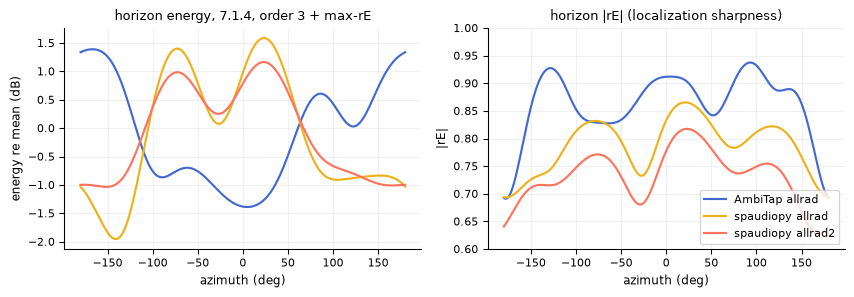

In [8]:
# ALLRAD: horizon metrics on 7.1.4 at order 3, max-rE weighting everywhere.
az_s = np.linspace(-np.pi, np.pi, 361)

def horizon_metrics(D, Y):
    G = D @ Y.T
    E = (G**2).sum(0)
    rE = (u.T @ G**2) / E
    return E / E.mean(), np.linalg.norm(rE, axis=0)

d_at = at.decoder_matrix("allrad", order, az_l, el_l, use_max_re=True)
Y_at = at.sh_matrix(order, az_s.astype(np.float32), np.zeros_like(az_s, dtype=np.float32))
E_at, re_at = horizon_metrics(d_at, Y_at)

wa = np.repeat(spa.sph.max_rE_weights(order), [2 * n + 1 for n in range(order + 1)])
Y_sp = spa.sph.sh_matrix(order, az_s, np.full_like(az_s, np.pi / 2), "real")
curves = {"AmbiTap allrad": (E_at, re_at)}
for name, fn in [("spaudiopy allrad", spa.decoder.allrad),
                 ("spaudiopy allrad2", spa.decoder.allrad2)]:
    D = np.asarray(fn(I, ls, N_sph=order)) * wa[None, :]
    curves[name] = horizon_metrics(D, Y_sp)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for i, (name, (E, re)) in enumerate(curves.items()):
    axes[0].plot(np.degrees(az_s), 10 * np.log10(E), color=PAL[i], lw=1.6, label=name)
    axes[1].plot(np.degrees(az_s), re, color=PAL[i], lw=1.6, label=name)
axes[0].set(xlabel="azimuth (deg)", ylabel="energy re mean (dB)",
            title="horizon energy, 7.1.4, order 3 + max-rE")
axes[1].set(xlabel="azimuth (deg)", ylabel="|rE|", ylim=(0.6, 1.0),
            title="horizon |rE| (localization sharpness)")
axes[1].legend(loc="lower right")
fig.tight_layout()

for name, (E, re) in curves.items():
    print(f"{name:18s}: energy ripple {E.max() / E.min():.3f}, mean |rE| {re.mean():.4f}")
# Different virtual designs -> different trade-offs; sanity-gate ours.
assert re_at.mean() > 0.85 and E_at.max() / E_at.min() < 2.0


## 6. Design-time performance

Construction cost matters for head-tracking (rotation) and for interactive
layout editing (decoders). Fairness note: spaudiopy is NumPy-based research
code and makes no real-time claims — this measures the workflow gap, not a
flaw. AmbiTap numbers are the compiled C++ through ctypes (which *adds*
call overhead to AmbiTap's side).


mode-match (o3, 7.1.4)  : ambitap   0.069 ms   spaudiopy   0.437 ms   (  6.4x)
EPAD (o3, 7.1.4)        : ambitap   0.072 ms   spaudiopy   0.390 ms   (  5.4x)
ALLRAD (o3, 7.1.4)      : ambitap   0.051 ms   spaudiopy   3.556 ms   ( 69.1x)
rotation matrix (o5)    : ambitap   0.016 ms   spaudiopy   2.421 ms   (148.4x)


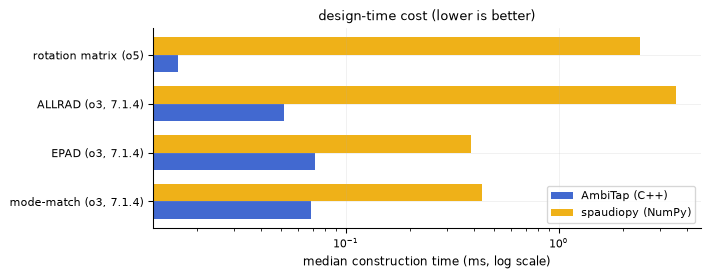

In [9]:
def bench_ms(f, n=9):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        f()
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts) * 1e3)

rows = [
    ("mode-match (o3, 7.1.4)",
     bench_ms(lambda: at.decoder_matrix("mode_match", order, az_l, el_l)),
     bench_ms(lambda: spa.decoder.mad(I, ls, N_sph=order))),
    ("EPAD (o3, 7.1.4)",
     bench_ms(lambda: at.decoder_matrix("epad", order, az_l, el_l)),
     bench_ms(lambda: spa.decoder.epad(I, ls, N_sph=order))),
    ("ALLRAD (o3, 7.1.4)",
     bench_ms(lambda: at.decoder_matrix("allrad", order, az_l, el_l)),
     bench_ms(lambda: spa.decoder.allrad(I, ls, N_sph=order))),
    ("rotation matrix (o5)",
     bench_ms(lambda: at.sh_rotation_matrix(5, 0.5, -0.2, 0.1)),
     bench_ms(lambda: spa.sph.sh_rotation_matrix(5, 0.5, -0.2, 0.1, sh_type="real"))),
]

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ypos = np.arange(len(rows))
ax.barh(ypos - 0.18, [r[1] for r in rows], height=0.36, color=PAL[0], label="AmbiTap (C++)")
ax.barh(ypos + 0.18, [r[2] for r in rows], height=0.36, color=PAL[1], label="spaudiopy (NumPy)")
ax.set(yticks=ypos, yticklabels=[r[0] for r in rows], xscale="log",
       xlabel="median construction time (ms, log scale)",
       title="design-time cost (lower is better)")
ax.legend()
fig.tight_layout()

for name, a, b in rows:
    print(f"{name:24s}: ambitap {a:7.3f} ms   spaudiopy {b:7.3f} ms   ({b / a:5.1f}x)")


## Summary

- **SH basis**: agrees with spaudiopy, pyshtools, and SciPy — three
  codebases with no shared lineage — through exactly-derived convention
  maps (< 1e-5).
- **Rotation**: AmbiTap's Ivanic–Ruedenberg recurrence matches spaudiopy's
  Wigner-D construction to float precision at every order tested, under
  the documented frame/field convention flip.
- **max-rE weights**: identical.
- **VBAP**: both libraries satisfy the defining invariants exactly
  (unit power, exact velocity-vector direction); gain vectors are
  identical whenever both pick the same triangle, and differ only on
  square-face diagonal ties, where both answers are equally valid.
- **Mode-matching & EPAD decoders: matrix-identical** up to the basis
  conversion and a fixed absolute-gain convention offset (residual < 1e-5).
- **ALLRAD** differs by design (virtual-layout choice): on 7.1.4/order 3,
  AmbiTap's t-design construction gives the sharpest imaging (mean |rE|)
  with energy flatness between spaudiopy's two variants.
- **Design-time**: AmbiTap constructs decoders ~5–70× and rotation
  matrices ~150× faster — the margin that makes per-block head-tracked
  rotation rebuilds practical.

The narrative comparison — including the C++ ecosystem
(libspatialaudio, SAF, IEM, Resonance Audio) on feature axes — lives in
`docs/COMPARISON.md`.
